In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('../')
from simulation.core import SimulationParams, SimulationRunner
import matplotlib.pyplot as plt
import pandas as pd
import os
import glob

In [2]:
params_baseline = SimulationParams(
    enable_logging=True,
    n_snipers=0
)
runner_baseline = SimulationRunner(params_baseline)
result_baseline = runner_baseline.run()
print(f'Without snipers — total events: {result_baseline.total_events:,}')
print(f'  Investor trades: {result_baseline.investor_trades:,}')

Logging to 20260602_130553_873545
Without snipers — total events: 509,004
  Investor trades: 26,338


In [3]:
params_scenario1 = SimulationParams(
    enable_logging=True,
    mm_lag=0.01,
    sniper_lag=0.001,
    order_submission_delay=0,
    n_snipers=2
)
runner_scenario1 = SimulationRunner(params_scenario1)
result_scenario1 = runner_scenario1.run()
print(f'With snipers — total events: {result_scenario1.total_events:,}')
print(f'  Sniper  trades: {result_scenario1.sniper1_trades:,}   PnL: {result_scenario1.sniper1_pnl:.4f}')
# print(f'  Sniper 2 trades: {result_scenario1.sniper2_trades:,}   PnL: {result_scenario1.sniper2_pnl:.4f}')
print(f'  Investor trades: {result_scenario1.investor_trades:,}')

Logging to 20260602_130654_601975
With snipers — total events: 468,803
  Sniper  trades: 6,078   PnL: 274.4300
  Investor trades: 28,273


In [4]:
params_scenario2 = SimulationParams(
    enable_logging=True,
    mm_lag=0.001,
    sniper_lag=0.001,
    order_submission_delay=0,
    n_snipers=10
)
runner_scenario2 = SimulationRunner(params_scenario2)
result_scenario2 = runner_scenario2.run()
print(f'With snipers — total events: {result_scenario2.total_events:,}')
print(f'  Sniper 1 trades: {result_scenario2.sniper1_trades:,}   PnL: {result_scenario2.sniper1_pnl:.4f}')
print(f'  Sniper 2 trades: {result_scenario2.sniper2_trades:,}   PnL: {result_scenario2.sniper2_pnl:.4f}')
print(f'  Investor trades: {result_scenario2.investor_trades:,}')

Logging to 20260602_130801_115624
With snipers — total events: 1,277,756
  Sniper 1 trades: 2,169   PnL: 101.0200
  Sniper 2 trades: 2,170   PnL: 98.2800
  Investor trades: 28,082


In [5]:
params_scenario3 = SimulationParams(
    enable_logging=True,
    mm_lag=0.01,
    sniper_lag=0.001,
    order_submission_delay=0.005,
    n_snipers=2
)
runner_scenario3 = SimulationRunner(params_scenario3)
result_scenario3 = runner_scenario3.run()
print(f'With snipers — total events: {result_scenario3.total_events:,}')
print(f'  Sniper 1 trades: {result_scenario3.sniper1_trades:,}   PnL: {result_scenario3.sniper1_pnl:.4f}')
print(f'  Sniper 2 trades: {result_scenario3.sniper2_trades:,}   PnL: {result_scenario3.sniper2_pnl:.4f}')
print(f'  Investor trades: {result_scenario3.investor_trades:,}')

Logging to 20260602_131014_068384
With snipers — total events: 741,637
  Sniper 1 trades: 3,745   PnL: 152.5500
  Sniper 2 trades: 3,748   PnL: 152.8000
  Investor trades: 27,861


In [6]:
params_scenario4 = SimulationParams(
    enable_logging=True,
    mm_lag=0.01,
    sniper_lag=0.001,
    order_submission_delay=0.011,
    n_snipers=2
)
runner_scenario4 = SimulationRunner(params_scenario4)
result_scenario4 = runner_scenario4.run()
print(f'With snipers — total events: {result_scenario4.total_events:,}')
print(f'  Sniper 1 trades: {result_scenario4.sniper1_trades:,}   PnL: {result_scenario4.sniper1_pnl:.4f}')
print(f'  Sniper 2 trades: {result_scenario4.sniper2_trades:,}   PnL: {result_scenario4.sniper2_pnl:.4f}')
print(f'  Investor trades: {result_scenario4.investor_trades:,}')

Logging to 20260602_131135_663495
With snipers — total events: 734,164
  Sniper 1 trades: 0   PnL: 0.0000
  Sniper 2 trades: 0   PnL: 0.0000
  Investor trades: 27,287


In [7]:
def pnl_series(history, key):
    times  = [h['time'] for h in history]
    values = [h[key]    for h in history]
    return times, values


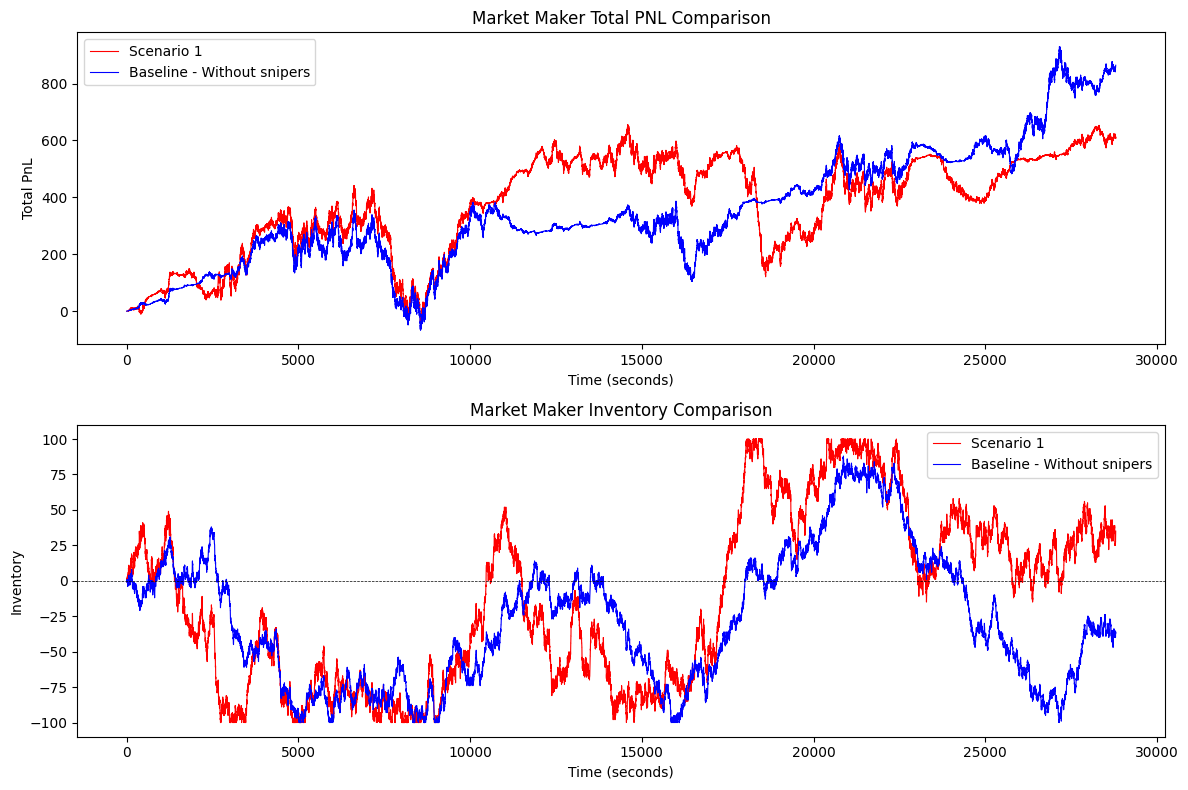

In [8]:

#fig, (ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8) = plt.subplots(2, 1, figsize=(12, 8), sharex=False)
fig, (ax1, ax5) = plt.subplots(2, 1, figsize=(12, 8), sharex=False)
# Panel (a) — total PnL
t_1, pnl_1 = pnl_series(result_scenario1.mm_pnl_history,    'total_pnl')
t_n, pnl_n = pnl_series(result_baseline.mm_pnl_history, 'total_pnl')
ax1.plot(t_1, pnl_1, color='red',  linewidth=0.8, label='Scenario 1')
ax1.plot(t_n, pnl_n, color='blue', linewidth=0.8, label='Baseline - Without snipers')
ax1.set_title('Market Maker Total PNL Comparison')
ax1.set_xlabel('Time (seconds)')
ax1.set_ylabel('Total PnL')
ax1.legend()
ax1.yaxis.set_major_formatter(plt.matplotlib.ticker.ScalarFormatter(useOffset=False))
# Panel (b) — inventory
t_n, inv_n = pnl_series(result_baseline.mm_pnl_history, 'inventory')
t_1, inv_1 = pnl_series(result_scenario1.mm_pnl_history,    'inventory')
ax5.plot(t_1, inv_1, color='red',  linewidth=0.8, label='Scenario 1')
ax5.plot(t_n, inv_n, color='blue', linewidth=0.8, label='Baseline - Without snipers')
ax5.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax5.set_title('Market Maker Inventory Comparison')
ax5.set_xlabel('Time (seconds)')
ax5.set_ylabel('Inventory')
ax5.legend()

plt.tight_layout()
plt.show()


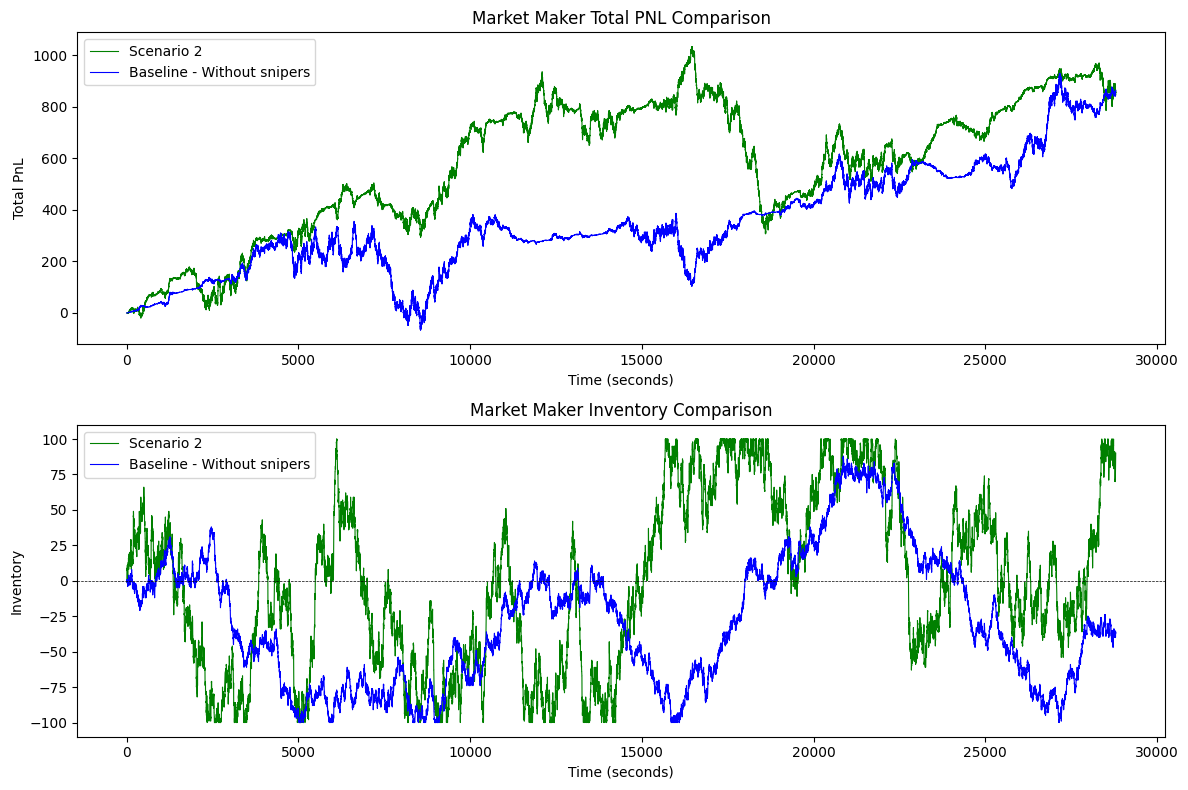

In [9]:

fig, (ax2, ax6) = plt.subplots(2, 1, figsize=(12, 8), sharex=False)
# Panel (a) — total PnL
t_2, pnl_2 = pnl_series(result_scenario2.mm_pnl_history,    'total_pnl')
t_n, pnl_n = pnl_series(result_baseline.mm_pnl_history, 'total_pnl')
ax2.plot(t_2, pnl_2, color='green',  linewidth=0.8, label='Scenario 2')
ax2.plot(t_n, pnl_n, color='blue', linewidth=0.8, label='Baseline - Without snipers')
ax2.set_title('Market Maker Total PNL Comparison')
ax2.set_xlabel('Time (seconds)')
ax2.set_ylabel('Total PnL')
ax2.legend()
ax2.yaxis.set_major_formatter(plt.matplotlib.ticker.ScalarFormatter(useOffset=False))
# Panel (b) — inventory
t_n, inv_n = pnl_series(result_baseline.mm_pnl_history, 'inventory')
t_2, inv_2 = pnl_series(result_scenario2.mm_pnl_history,    'inventory')
ax6.plot(t_2, inv_2, color='green',  linewidth=0.8, label='Scenario 2')
ax6.plot(t_n, inv_n, color='blue', linewidth=0.8, label='Baseline - Without snipers')
ax6.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax6.set_title('Market Maker Inventory Comparison')
ax6.set_xlabel('Time (seconds)')
ax6.set_ylabel('Inventory')
ax6.legend()

plt.tight_layout()
plt.show()


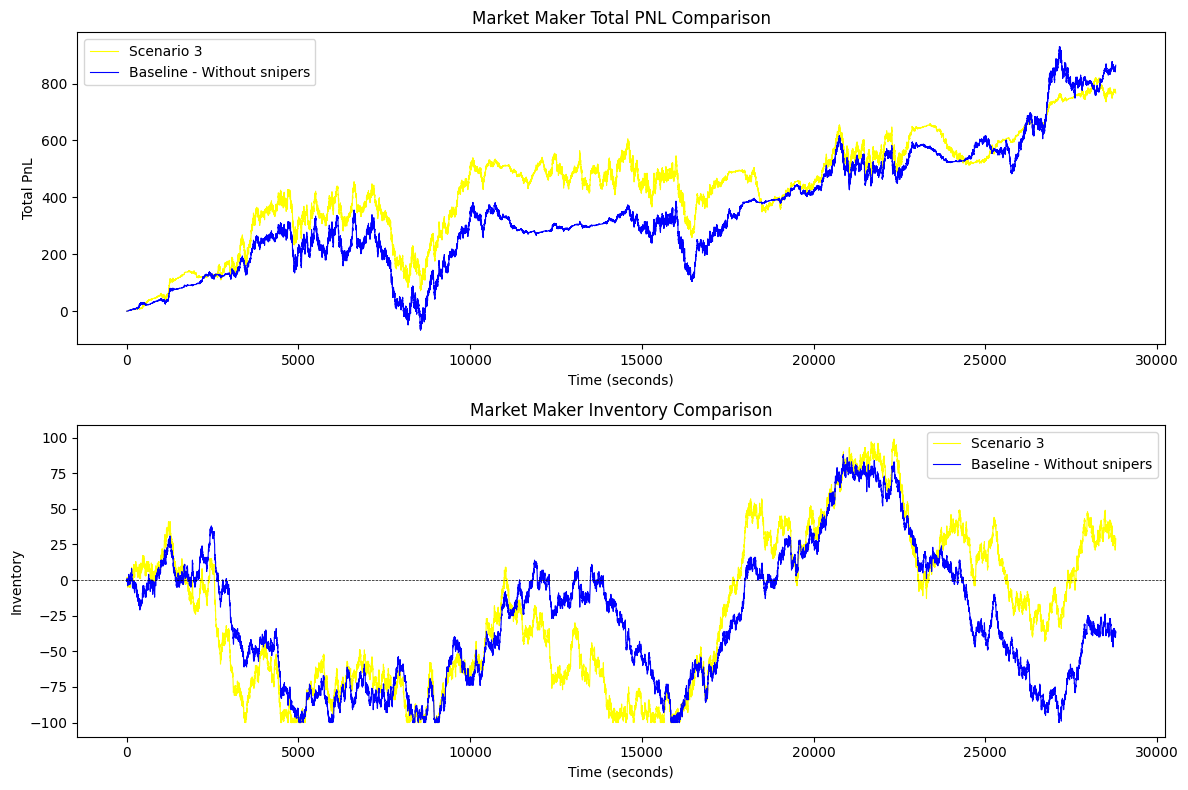

In [10]:

fig, (ax3, ax7) = plt.subplots(2, 1, figsize=(12, 8), sharex=False)
# Panel (a) — total PnL
t_3, pnl_3 = pnl_series(result_scenario3.mm_pnl_history,    'total_pnl')
t_n, pnl_n = pnl_series(result_baseline.mm_pnl_history, 'total_pnl')
ax3.plot(t_3, pnl_3, color='yellow',  linewidth=0.8, label='Scenario 3')
ax3.plot(t_n, pnl_n, color='blue', linewidth=0.8, label='Baseline - Without snipers')
ax3.set_title('Market Maker Total PNL Comparison')
ax3.set_xlabel('Time (seconds)')
ax3.set_ylabel('Total PnL')
ax3.legend()
ax3.yaxis.set_major_formatter(plt.matplotlib.ticker.ScalarFormatter(useOffset=False))
# Panel (b) — inventory
t_n, inv_n = pnl_series(result_baseline.mm_pnl_history, 'inventory')
t_3, inv_3 = pnl_series(result_scenario3.mm_pnl_history,    'inventory')
ax7.plot(t_3, inv_3, color='yellow',  linewidth=0.8, label='Scenario 3')
ax7.plot(t_n, inv_n, color='blue', linewidth=0.8, label='Baseline - Without snipers')
ax7.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax7.set_title('Market Maker Inventory Comparison')
ax7.set_xlabel('Time (seconds)')
ax7.set_ylabel('Inventory')
ax7.legend()

plt.tight_layout()
plt.show()


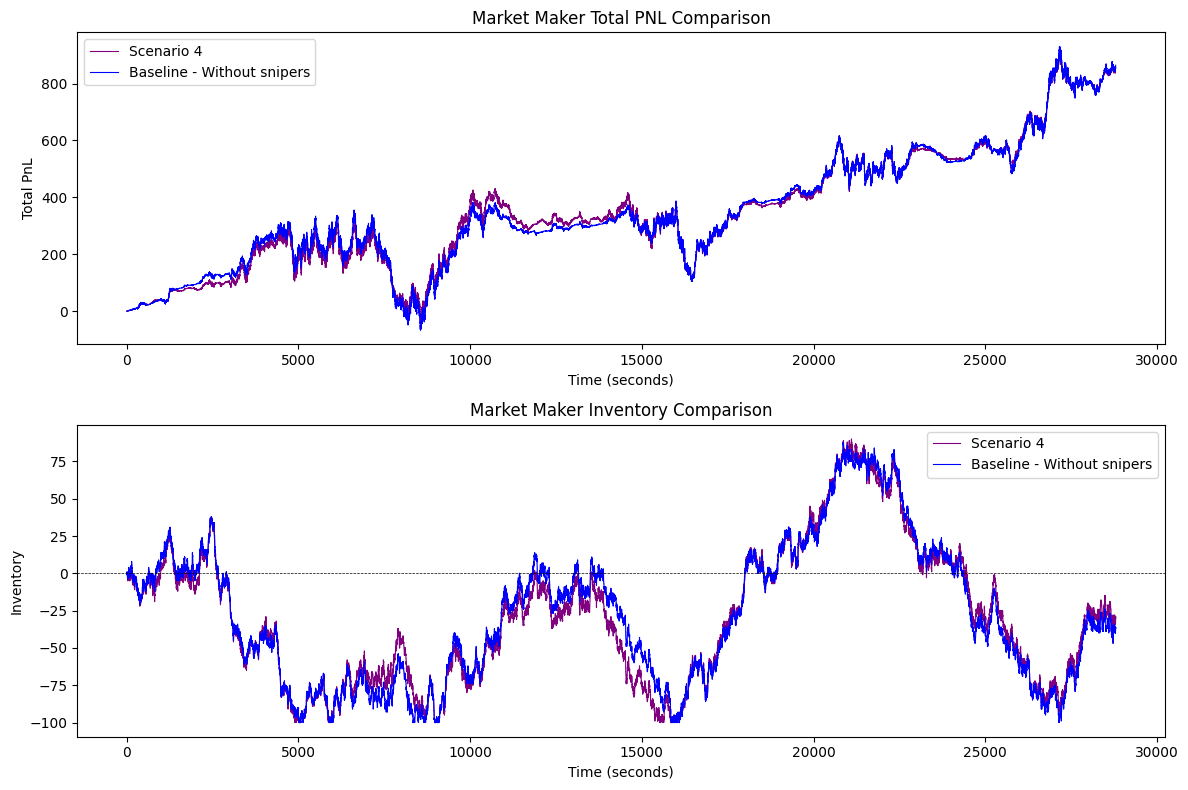

In [11]:

fig, (ax4, ax8) = plt.subplots(2, 1, figsize=(12, 8), sharex=False)
# Panel (a) — total PnL
t_4, pnl_4 = pnl_series(result_scenario4.mm_pnl_history,    'total_pnl')
t_n, pnl_n = pnl_series(result_baseline.mm_pnl_history, 'total_pnl')
ax4.plot(t_4, pnl_4, color='purple',  linewidth=0.8, label='Scenario 4')
ax4.plot(t_n, pnl_n, color='blue', linewidth=0.8, label='Baseline - Without snipers')
ax4.set_title('Market Maker Total PNL Comparison')
ax4.set_xlabel('Time (seconds)')
ax4.set_ylabel('Total PnL')
ax4.legend()
ax4.yaxis.set_major_formatter(plt.matplotlib.ticker.ScalarFormatter(useOffset=False))
# Panel (b) — inventory
t_n, inv_n = pnl_series(result_baseline.mm_pnl_history, 'inventory')
t_4, inv_4 = pnl_series(result_scenario4.mm_pnl_history,    'inventory')
ax8.plot(t_4, inv_4, color='purple',  linewidth=0.8, label='Scenario 4')
ax8.plot(t_n, inv_n, color='blue', linewidth=0.8, label='Baseline - Without snipers')
ax8.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax8.set_title('Market Maker Inventory Comparison')
ax8.set_xlabel('Time (seconds)')
ax8.set_ylabel('Inventory')
ax8.legend()

plt.tight_layout()
plt.show()

In [12]:
print(f'Baseline — avg_spread: {result_baseline.avg_spread:,}')
print(f'Scenario 1 — avg_spread: {result_scenario1.avg_spread:,}')
print(f'Scenario 2 — avg_spread: {result_scenario2.avg_spread:,}')
print(f'Scenario 3 — avg_spread: {result_scenario3.avg_spread:,}')
print(f'Scenario 4 — avg_spread: {result_scenario4.avg_spread:,}')

Baseline — avg_spread: 0.05725202768881995
Scenario 1 — avg_spread: 0.0902839029202029
Scenario 2 — avg_spread: 0.10378083333333328
Scenario 3 — avg_spread: 0.07747903694479041
Scenario 4 — avg_spread: 0.057518388773058746


In [13]:
def last(history, key):
    return history[-1][key] if history else float('nan')



In [14]:
cum_bas = last(result_baseline.mm_pnl_history,'total_pnl')
cum_1 = cum_bas + last(result_scenario1.mm_pnl_history,'total_pnl')
cum_2 = cum_1 + last(result_scenario2.mm_pnl_history,'total_pnl')
cum_3 = cum_2 + last(result_scenario3.mm_pnl_history,'total_pnl')
cum_4 = cum_3 + last(result_scenario4.mm_pnl_history,'total_pnl')

rows = [
    ('MM Cumulative Total PNL - Baseline',       f"{cum_bas:>14.4f}"),
    ('MM Cumulative Total PNL - Scenario1',       f"{cum_1:>14.4f}"),
    ('MM Cumulative Total PNL - Scenario2',       f"{cum_2:>14.4f}"),
    ('MM Cumulative Total PNL - Scenario3',       f"{cum_3:>14.4f}"),
    ('MM Cumulative Total PNL - Scenario4',       f"{cum_4:>14.4f}")
]

for label, val in rows:
    print(f"{label:28}  {val} ")


MM Cumulative Total PNL - Baseline        864.2400 
MM Cumulative Total PNL - Scenario1       1471.2100 
MM Cumulative Total PNL - Scenario2       2317.5700 
MM Cumulative Total PNL - Scenario3       3084.0900 
MM Cumulative Total PNL - Scenario4       3940.2200 
